In [130]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.tsa.stattools import adfuller

In [131]:
df = pd.read_csv("/Users/cyriaque/timeseries-arma-sarima-forecast/serie", sep= " ", header=None, names=["t", "Xt"])

In [132]:
df.head()


,t,Xt
0,1,4.260665
1,2,3.519952
2,3,3.116867
3,4,3.893221
4,5,2.669689


In [133]:
df.dtypes

t       int64
Xt    float64
dtype: object

In [134]:
df["Xt"]=df["Xt"].astype(float)

In [135]:
df.dtypes

t       int64
Xt    float64
dtype: object

In [136]:
df.shape

(1000, 2)

In [137]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   t       1000 non-null   int64  
 1   Xt      1000 non-null   float64
dtypes: float64(1), int64(1)
memory usage: 15.8 KB


In [138]:
df.describe()

,t,Xt
count,1000.000000,1000.000000
mean,500.500000,5.954972
std,288.819436,3.800264
min,1.000000,-4.563925
25%,250.750000,3.279229
50%,500.500000,5.957459
75%,750.250000,8.623957
max,1000.000000,16.235243


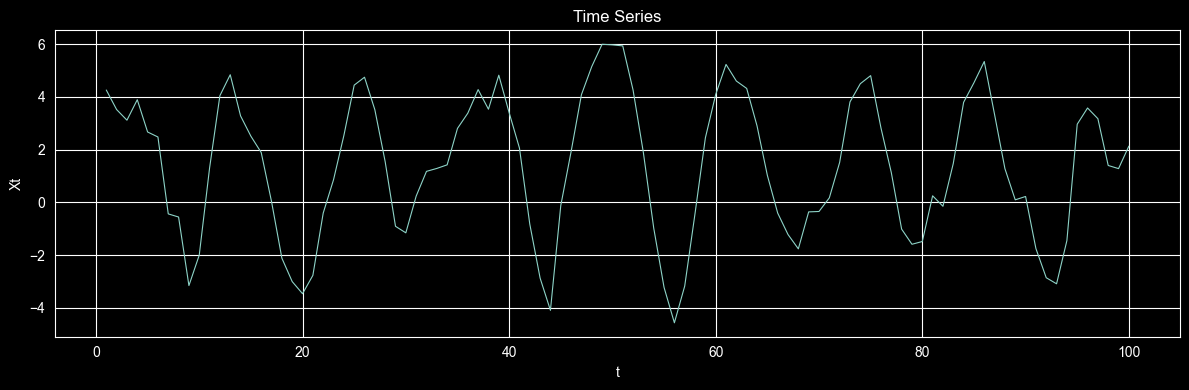

In [129]:
plt.figure(figsize=(12, 4))
plt.plot(df["t"][:100], df["Xt"][:100], linewidth=0.8)
plt.title("Time Series")
plt.xlabel("t")
plt.ylabel("Xt")
plt.tight_layout()
plt.show()

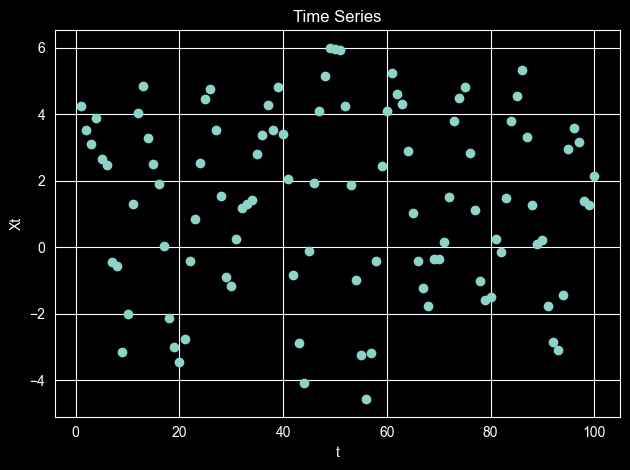

In [115]:
plt.scatter(df["t"][:100], df["Xt"][:100])
plt.title("Time Series")
plt.xlabel("t")
plt.ylabel("Xt")
plt.tight_layout()
plt.show()


Considering only 100 observations we cannot observe any tendency.

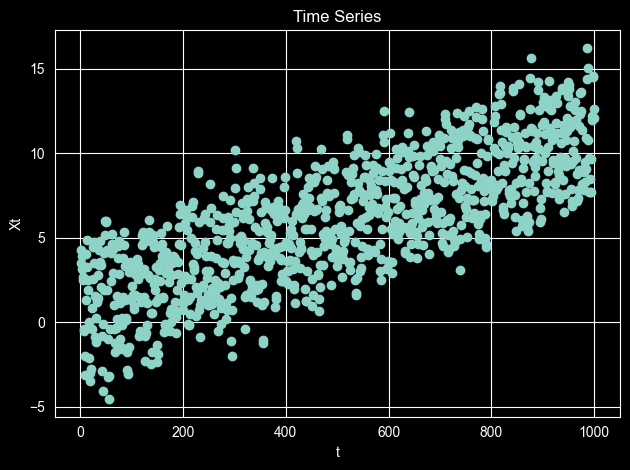

In [116]:
plt.scatter(df["t"], df["Xt"])
plt.title("Time Series")
plt.xlabel("t")
plt.ylabel("Xt")
plt.tight_layout()
plt.show()


However with all the observations there is clearly a tendency.

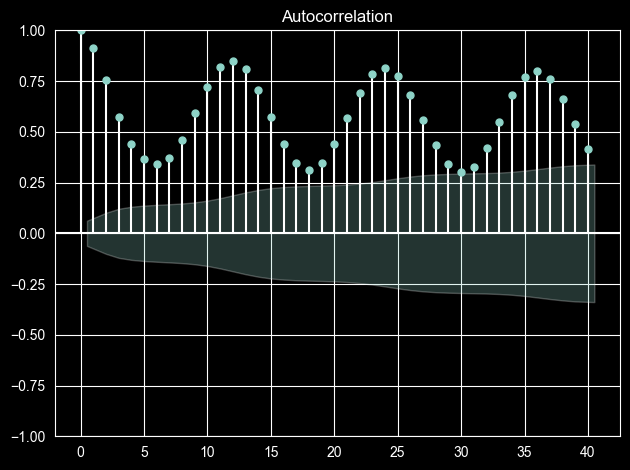

In [49]:
plot_acf(df["Xt"], lags=40)
plt.tight_layout()
plt.show()

slow decay: the ACF decreases very slowly and stay well above the confidence band for all 40 lag, so we can assume that it is a non stationary series.

Periodic pattern : The ACF goes up and down which suggest a seasonality in the series.

No quick drop to zero : An ARMA would have an ACF dropping to zero exponentially quickly. That is not the case here which suggest non-stationarity.
Mathematically it probably means that the series has a unit root.

Since ACF decays slowly we can try to differentiate (I-B)^d Xt until the ACF function decays quickly


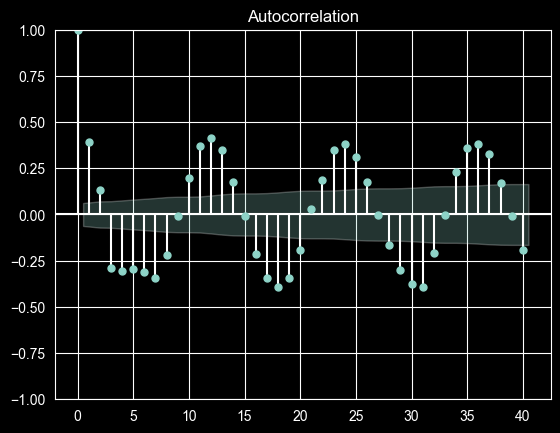

In [110]:
diff1_Xt = df["Xt"].diff(1).dropna()
plot_acf(diff1_Xt, lags=40)
plt.show()

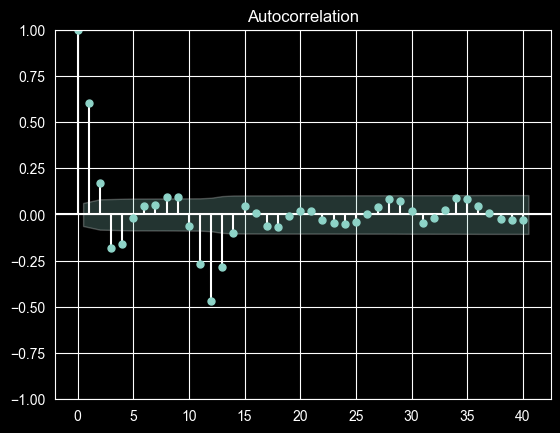

In [113]:
diff12_Xt = df["Xt"].diff(12).dropna()
plot_acf(diff12_Xt, lags=40)
plt.show()

We can observe that by differentiating 1,2,3,4 or 20 or 30 times,... doesn't change anything about the convergence speed. But it does by differienciating 12,24,36 so we're probably not dealing with an ARIMA(p,d,q) but with a SARIMA(p,d,q)(P,D,Q)[12]

An other method to see that would have been with the one of Dickey and Fuller.


H0 : The series has a unit root --> non-stationary


H1 : The series is stationary

In [118]:
result = adfuller(df["Xt"])
print(f"ADF statistic: {result[0]:.4f}")
print(f"p-value: {result[1]:.4f}")

ADF statistic: -1.0171
p-value: 0.7470


Here the p-value is greater than 0.05 so we do not reject H0. Hence the series is likely non-stationary which means that it cannot be estimate by an ARMA, we need an ARIMA or a SARIMA, this is coherent with what we have observe on the ACF graphics.
